# CS1 — EXP-0 OOV and Project-Vocabulary Diagnostic (Development Only)

**Purpose.** Test whether unseen / project-specific lexical vocabulary is associated with weaker project-disjoint EXP-0 performance.

This notebook is a **read-only diagnostic**. It does not retrain a classifier, modify any source module, tune a hyperparameter, access any outer-holdout prediction, or alter the locked model-selection record.

It reloads saved development OOF predictions for:

- fixed EXP-0 baseline; and
- nested-alpha EXP-0 sensitivity study.

It then refits only the **word TF-IDF vectorizer** once per frozen development fold so that OOV coverage can be reconstructed from the exact training vocabulary. The character vectorizer and SGD classifier are not fitted.

## Questions answered

1. What fraction of each held-out function's lexical tokens were never observed in that fold's training code (**raw lexical OOV**)?
2. What fraction were absent from the fitted TF-IDF unigram vocabulary (**model-vocabulary OOV**)?
3. Do high-OOV vulnerable functions receive lower risk scores or become false negatives more often?
4. How many selected word-unigram features occur in only one training project, fewer than five projects, or many projects?

**Boundary:** all metrics are computed only on the frozen 80% development partition and its five project-grouped folds.


In [1]:
# ============================================================================
# 1. Mount Drive and obtain the repository source code
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import subprocess
import sys

REPO_URL = 'https://github.com/EnomisLP/DiverseVul--IS-Project.git'
REPO_BRANCH = 'prashant'
REPO_ROOT = Path('/content/DiverseVul--IS-Project')
PROJECT_DIR = REPO_ROOT / 'vuln-detection'
SRC_DIR = PROJECT_DIR / 'src'
EXPECTED_EXP0 = SRC_DIR / 'case_study_1' / 'exp0' / 'exp0_lr.py'


def run_command(command):
    subprocess.run(command, check=True)


if not REPO_ROOT.is_dir():
    print('Cloning repository...')
    run_command([
        'git', 'clone', '--branch', REPO_BRANCH, '--single-branch',
        REPO_URL, str(REPO_ROOT),
    ])
else:
    print('Refreshing repository branch...')
    run_command(['git', '-C', str(REPO_ROOT), 'fetch', 'origin', REPO_BRANCH])
    run_command(['git', '-C', str(REPO_ROOT), 'checkout', REPO_BRANCH])
    run_command(['git', '-C', str(REPO_ROOT), 'pull', '--ff-only', 'origin', REPO_BRANCH])

if not EXPECTED_EXP0.is_file():
    raise FileNotFoundError(
        'Expected EXP-0 source module is missing.\n'
        f'Expected: {EXPECTED_EXP0}\n'
        'Confirm that the repository layout is '        'DiverseVul--IS-Project/vuln-detection/src/case_study_1/...'
    )

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Repository root:', REPO_ROOT)
print('Project root:', PROJECT_DIR)
print('Source path:', SRC_DIR)
run_command(['git', '-C', str(REPO_ROOT), 'log', '-1', '--oneline'])


Mounted at /content/drive
Cloning repository...
Repository root: /content/DiverseVul--IS-Project
Project root: /content/DiverseVul--IS-Project/vuln-detection
Source path: /content/DiverseVul--IS-Project/vuln-detection/src


In [2]:
# ============================================================================
# 2. Imports, immutable paths, and development-only boundaries
# ============================================================================

from __future__ import annotations

from datetime import datetime, timezone
import gc
import hashlib
import json
from pathlib import Path
import re
import time

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, precision_score, recall_score

from case_study_1.exp0 import exp0_lr

DRIVE_ROOT = Path('/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData')
PROCESSED_DIR = DRIVE_ROOT / 'processed'
MANIFEST_ROOT = DRIVE_ROOT / 'manifests'
OUTPUT_ROOT = DRIVE_ROOT / 'outputs'

EXPERIMENT_ID = 'cs1_project_holdout20_innercv_v1'
EXPERIMENT_MANIFEST_DIR = MANIFEST_ROOT / EXPERIMENT_ID
EXPERIMENT_OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID

NORMALIZED_DATA_PATH = PROCESSED_DIR / 'rdiversevul_cs1_normalized_v1.parquet'
INNER_MANIFEST_PATH = (
    EXPERIMENT_MANIFEST_DIR / 'inner_cv' /
    'cs1_project_grouped_5fold_manifest.parquet'
)

# These are development-only OOF artifacts already created in the prior runs.
FIXED_EXP0_OOF_PATH = (
    EXPERIMENT_OUTPUT_DIR / 'exp0_inner_cv_clean_reproduction_v1' /
    'cs1_exp0_lr_oof_predictions.parquet'
)
NESTED_EXP0_OOF_PATH = (
    EXPERIMENT_OUTPUT_DIR / 'exp0_nested_alpha_tuning_development_only_v1' /
    'cs1_exp0_nested_alpha_dev_grouped_oof_predictions.parquet'
)

# New diagnostic output only. It never writes into an experiment-result folder.
DIAGNOSTIC_DIR = (
    EXPERIMENT_OUTPUT_DIR / 'diagnostics' /
    'exp0_oov_project_vocab_audit_v1'
)
CHECKPOINT_DIR = DIAGNOSTIC_DIR / 'checkpoints'

# Safe resume: per-fold diagnostic checkpoints are loaded when present.
RESUME_FROM_CHECKPOINTS = True
FORCE_RECOMPUTE_ALL_FOLDS = False

for path in [NORMALIZED_DATA_PATH, INNER_MANIFEST_PATH, FIXED_EXP0_OOF_PATH, NESTED_EXP0_OOF_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f'Missing required saved input artifact:\n{path}')

DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('Normalized cache:', NORMALIZED_DATA_PATH)
print('Frozen development manifest:', INNER_MANIFEST_PATH)
print('Fixed EXP-0 OOF:', FIXED_EXP0_OOF_PATH)
print('Nested EXP-0 OOF:', NESTED_EXP0_OOF_PATH)
print('Diagnostic output:', DIAGNOSTIC_DIR)
print('\nGlobal outer-holdout manifest is deliberately not loaded by this notebook.')


Normalized cache: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/processed/rdiversevul_cs1_normalized_v1.parquet
Frozen development manifest: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/manifests/cs1_project_holdout20_innercv_v1/inner_cv/cs1_project_grouped_5fold_manifest.parquet
Fixed EXP-0 OOF: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp0_inner_cv_clean_reproduction_v1/cs1_exp0_lr_oof_predictions.parquet
Nested EXP-0 OOF: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp0_nested_alpha_tuning_development_only_v1/cs1_exp0_nested_alpha_dev_grouped_oof_predictions.parquet
Diagnostic output: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/diagnostics/exp0_oov_project_vocab_audit_v1

Global outer-holdout manifest is delib

In [3]:
# ============================================================================
# 3. Load and validate only the frozen development-fold rows and saved scores
# ============================================================================

INNER_COLUMNS = ['source_row_id', 'label', 'project', 'fold']
inner_manifest_df = pd.read_parquet(INNER_MANIFEST_PATH)
missing_inner = sorted(set(INNER_COLUMNS) - set(inner_manifest_df.columns))
if missing_inner:
    raise KeyError(f'Inner manifest is missing columns: {missing_inner}')

inner_manifest_df = inner_manifest_df[INNER_COLUMNS].copy()
inner_manifest_df['fold'] = pd.to_numeric(inner_manifest_df['fold'], errors='raise').astype('int8')
inner_manifest_df['label'] = pd.to_numeric(inner_manifest_df['label'], errors='raise').astype('int8')

if inner_manifest_df['source_row_id'].duplicated().any():
    raise ValueError('Inner manifest contains duplicate source_row_id values.')
if set(inner_manifest_df['fold'].unique()) != set(range(5)):
    raise ValueError('Expected exactly frozen development folds {0,1,2,3,4}.')
if set(inner_manifest_df['label'].unique()) != {0, 1}:
    raise ValueError('Development manifest does not contain both label classes.')

# The full parquet is read only to retrieve code for IDs in the frozen inner manifest.
# Immediately after the merge, all non-development rows are discarded and are never scored.
normalized_df = pd.read_parquet(
    NORMALIZED_DATA_PATH,
    columns=['source_row_id', 'normalized_code', 'label', 'project'],
)

dev_df = inner_manifest_df.merge(
    normalized_df,
    on='source_row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_manifest', '_data'),
)
del normalized_df
gc.collect()

if dev_df['normalized_code'].isna().any():
    raise ValueError('Some inner-manifest IDs are absent from the normalized dataset.')
if not np.array_equal(dev_df['label_manifest'].to_numpy(), dev_df['label_data'].to_numpy()):
    raise ValueError('Label mismatch between inner manifest and normalized dataset.')
if not np.array_equal(dev_df['project_manifest'].astype(str).to_numpy(), dev_df['project_data'].astype(str).to_numpy()):
    raise ValueError('Project mismatch between inner manifest and normalized dataset.')

dev_df = dev_df.rename(columns={
    'label_manifest': 'label',
    'project_manifest': 'project',
}).drop(columns=['label_data', 'project_data'])
dev_df['normalized_code'] = dev_df['normalized_code'].fillna('').astype(str)

if (dev_df['normalized_code'].str.strip() == '').any():
    raise ValueError('Development diagnostic frame contains empty normalized_code values.')


def load_and_validate_oof(path: Path, score_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    required = {'source_row_id', 'fold', 'label', 'y_score'}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise KeyError(f'{path.name} is missing OOF columns: {missing}')
    frame = frame[['source_row_id', 'fold', 'label', 'y_score']].copy()
    frame['fold'] = pd.to_numeric(frame['fold'], errors='raise').astype('int8')
    frame['label'] = pd.to_numeric(frame['label'], errors='raise').astype('int8')
    frame['y_score'] = pd.to_numeric(frame['y_score'], errors='raise').astype(float)
    if frame['source_row_id'].duplicated().any():
        raise ValueError(f'{path.name} has duplicate source_row_id values.')
    if not frame['y_score'].between(0.0, 1.0).all():
        raise ValueError(f'{path.name} has scores outside [0, 1].')
    frame = frame.rename(columns={'y_score': score_name})
    return frame

fixed_oof = load_and_validate_oof(FIXED_EXP0_OOF_PATH, 'score_fixed_exp0')
nested_oof = load_and_validate_oof(NESTED_EXP0_OOF_PATH, 'score_nested_exp0')

for name, frame in [('fixed', fixed_oof), ('nested', nested_oof)]:
    if set(frame['source_row_id']) != set(dev_df['source_row_id']):
        raise ValueError(f'{name} OOF IDs do not exactly match frozen development IDs.')
    expected = dev_df[['source_row_id', 'fold', 'label']].merge(
        frame[['source_row_id', 'fold', 'label']],
        on='source_row_id', how='inner', validate='one_to_one', suffixes=('_manifest', '_oof')
    )
    if not np.array_equal(expected['fold_manifest'].to_numpy(), expected['fold_oof'].to_numpy()):
        raise ValueError(f'{name} OOF fold assignments do not match the frozen manifest.')
    if not np.array_equal(expected['label_manifest'].to_numpy(), expected['label_oof'].to_numpy()):
        raise ValueError(f'{name} OOF labels do not match the frozen manifest.')

dev_df = (
    dev_df
    .merge(fixed_oof[['source_row_id', 'score_fixed_exp0']], on='source_row_id', how='left', validate='one_to_one')
    .merge(nested_oof[['source_row_id', 'score_nested_exp0']], on='source_row_id', how='left', validate='one_to_one')
    .sort_values('source_row_id', kind='stable')
    .reset_index(drop=True)
)

if dev_df[['score_fixed_exp0', 'score_nested_exp0']].isna().any().any():
    raise ValueError('Missing saved OOF scores after merge.')

print('Development rows:', f'{len(dev_df):,}')
print('Development projects:', f'{dev_df.project.nunique():,}')
print('Development positive rate:', f'{dev_df.label.mean():.4%}')
print('Fold sizes:', dev_df.groupby('fold').size().to_dict())
print('\nValidated: saved fixed and nested OOF scores are aligned to exactly the same frozen development rows.')


Development rows: 203,958
Development projects: 594
Development positive rate: 5.2594%
Fold sizes: {0: 55509, 1: 40791, 2: 39072, 3: 35016, 4: 33570}

Validated: saved fixed and nested OOF scores are aligned to exactly the same frozen development rows.


In [4]:
# ============================================================================
# 4. Diagnostic helpers — exact EXP-0 lexical tokenization and safe metrics
# ============================================================================

# This is exactly the baseline word-token pattern in exp0_lr._build_word_vectorizer.
# EXP-0 uses lowercase=False, so token case is preserved.
WORD_TOKEN_RE = re.compile(r'(?u)\b\w+\b')
BASE_CONFIG = exp0_lr.Exp0Config(verbose=False)


def lexical_tokens(code: str) -> list[str]:
    """Return lexical unigrams under the exact EXP-0 word token pattern."""
    return WORD_TOKEN_RE.findall(str(code))


def oov_statistics(tokens: list[str], raw_train_tokens: set[str], model_unigram_vocab: set[str]) -> dict:
    """Compute occurrence- and unique-type OOV rates for one held-out function."""
    token_count = len(tokens)
    unique_tokens = set(tokens)
    unique_count = len(unique_tokens)

    raw_oov_count = sum(token not in raw_train_tokens for token in tokens)
    model_oov_count = sum(token not in model_unigram_vocab for token in tokens)
    raw_unique_oov_count = sum(token not in raw_train_tokens for token in unique_tokens)
    model_unique_oov_count = sum(token not in model_unigram_vocab for token in unique_tokens)

    def rate(numerator: int, denominator: int) -> float:
        return float(numerator / denominator) if denominator else np.nan

    return {
        'word_token_count': int(token_count),
        'word_unique_token_count': int(unique_count),
        'raw_lexical_oov_token_count': int(raw_oov_count),
        'raw_lexical_oov_token_rate': rate(raw_oov_count, token_count),
        'raw_lexical_oov_unique_count': int(raw_unique_oov_count),
        'raw_lexical_oov_unique_rate': rate(raw_unique_oov_count, unique_count),
        'model_vocab_oov_token_count': int(model_oov_count),
        'model_vocab_oov_token_rate': rate(model_oov_count, token_count),
        'model_vocab_oov_unique_count': int(model_unique_oov_count),
        'model_vocab_oov_unique_rate': rate(model_unique_oov_count, unique_count),
    }


def project_support_by_feature(x_train_word, train_projects: pd.Series) -> tuple[np.ndarray, int]:
    """Return the number of distinct train projects in which each selected word feature appears."""
    project_codes, project_labels = pd.factorize(train_projects.astype(str), sort=True)
    n_docs, n_features = x_train_word.shape
    n_projects = len(project_labels)

    # Rows are projects and columns are documents. Multiplication by a binary
    # document-feature matrix yields a sparse project-feature presence matrix.
    project_document = csr_matrix(
        (
            np.ones(n_docs, dtype=np.uint8),
            (project_codes, np.arange(n_docs, dtype=np.int64)),
        ),
        shape=(n_projects, n_docs),
        dtype=np.uint8,
    )
    x_binary = x_train_word.copy().astype(np.uint8)
    x_binary.data = np.ones_like(x_binary.data, dtype=np.uint8)
    project_feature_presence = project_document @ x_binary
    support = np.asarray(project_feature_presence.getnnz(axis=0)).ravel().astype(np.int32)
    return support, int(n_projects)


def oov_quartiles_within_fold(frame: pd.DataFrame, value_column: str) -> pd.Series:
    """Assign Low→High quartiles within each frozen held-out fold."""
    ranked = frame[value_column].rank(method='first')
    return pd.qcut(ranked, q=4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])


def safe_pr_auc(labels: pd.Series, scores: pd.Series) -> float:
    labels = np.asarray(labels, dtype=np.int8)
    scores = np.asarray(scores, dtype=float)
    return float(average_precision_score(labels, scores)) if len(np.unique(labels)) == 2 else np.nan


def score_summary_by_group(frame: pd.DataFrame, group_columns: list[str], score_column: str, model_name: str) -> pd.DataFrame:
    rows = []
    for group_values, subset in frame.groupby(group_columns, observed=True, sort=True):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        y_true = subset['label'].astype(np.int8)
        y_score = subset[score_column].astype(float)
        y_pred = (y_score >= 0.50).astype(np.int8)
        positives = subset.loc[y_true == 1]
        positive_pred = (positives[score_column].to_numpy(dtype=float) >= 0.50).astype(np.int8)
        row = dict(zip(group_columns, group_values))
        row.update({
            'model': model_name,
            'n_functions': int(len(subset)),
            'n_vulnerable': int(y_true.sum()),
            'positive_rate': float(y_true.mean()),
            'mean_model_vocab_oov_rate': float(subset['model_vocab_oov_token_rate'].mean()),
            'mean_raw_lexical_oov_rate': float(subset['raw_lexical_oov_token_rate'].mean()),
            'mean_word_token_count': float(subset['word_token_count'].mean()),
            'pr_auc': safe_pr_auc(y_true, y_score),
            'precision_at_050': float(precision_score(y_true, y_pred, zero_division=0)),
            'recall_at_050': float(recall_score(y_true, y_pred, zero_division=0)),
            'false_negative_rate_at_050': float(1.0 - recall_score(y_true, y_pred, zero_division=0)),
            'vulnerable_mean_score': float(positives[score_column].mean()) if len(positives) else np.nan,
            'vulnerable_false_negative_rate_at_050': float(1.0 - positive_pred.mean()) if len(positives) else np.nan,
        })
        rows.append(row)
    return pd.DataFrame(rows)

print('Exact baseline word token pattern:', WORD_TOKEN_RE.pattern)
print('Word TF-IDF config:', {
    'ngram_range': BASE_CONFIG.word_ngram_range,
    'min_df': BASE_CONFIG.word_min_df,
    'max_df': BASE_CONFIG.word_max_df,
    'max_features': BASE_CONFIG.word_max_features,
    'lowercase': BASE_CONFIG.lowercase,
})


Exact baseline word token pattern: (?u)\b\w+\b
Word TF-IDF config: {'ngram_range': (1, 3), 'min_df': 3, 'max_df': 0.995, 'max_features': 50000, 'lowercase': False}


In [5]:
# ============================================================================
# 5. Reconstruct fold-specific OOV and project-vocabulary diagnostics
# ============================================================================

RUN_METADATA_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_oov_project_vocab_audit_metadata.json'
FINAL_PER_FUNCTION_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_oov_per_function.parquet'
FINAL_FOLD_SUMMARY_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_oov_fold_summary.csv'
FINAL_QUARTILE_SUMMARY_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_oov_quartile_metrics.csv'
FINAL_CORRELATION_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_oov_score_correlations.csv'
FINAL_PROJECT_DIVERSITY_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_project_vocab_diversity_summary.csv'
FINAL_PROJECT_SUPPORT_PATH = DIAGNOSTIC_DIR / 'cs1_exp0_project_vocab_unigram_support.parquet'

run_payload = {
    'diagnostic_name': 'cs1_exp0_oov_project_vocab_audit_v1',
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'scope': 'development_only_frozen_5fold_manifest',
    'global_outer_holdout_loaded_or_scored': False,
    'normalized_data_path': str(NORMALIZED_DATA_PATH),
    'inner_manifest_path': str(INNER_MANIFEST_PATH),
    'fixed_exp0_oof_path': str(FIXED_EXP0_OOF_PATH),
    'nested_exp0_oof_path': str(NESTED_EXP0_OOF_PATH),
    'word_token_pattern': WORD_TOKEN_RE.pattern,
    'word_tfidf_config': {
        'ngram_range': list(BASE_CONFIG.word_ngram_range),
        'min_df': BASE_CONFIG.word_min_df,
        'max_df': BASE_CONFIG.word_max_df,
        'max_features': BASE_CONFIG.word_max_features,
        'lowercase': BASE_CONFIG.lowercase,
        'sublinear_tf': BASE_CONFIG.sublinear_tf,
        'norm': BASE_CONFIG.tfidf_norm,
    },
}

# Do not silently mix a prior output folder with another diagnostic configuration.
if RUN_METADATA_PATH.exists():
    previous = json.loads(RUN_METADATA_PATH.read_text(encoding='utf-8'))
    comparable_keys = [
        'diagnostic_name', 'scope', 'normalized_data_path', 'inner_manifest_path',
        'fixed_exp0_oof_path', 'nested_exp0_oof_path', 'word_token_pattern',
        'word_tfidf_config',
    ]
    if any(previous.get(key) != run_payload.get(key) for key in comparable_keys):
        raise RuntimeError(
            'Existing diagnostic output has a different immutable input/configuration.\n'
            f'Use a new output version instead of mixing artifacts: {DIAGNOSTIC_DIR}'
        )
else:
    RUN_METADATA_PATH.write_text(json.dumps(run_payload, indent=2), encoding='utf-8')

fold_per_function = []
fold_diversity = []
fold_support = []
fold_runtime_rows = []

for fold_id in range(BASE_CONFIG.n_splits):
    per_function_checkpoint = CHECKPOINT_DIR / f'fold_{fold_id}_oov_per_function.parquet'
    diversity_checkpoint = CHECKPOINT_DIR / f'fold_{fold_id}_project_vocab_diversity.csv'
    support_checkpoint = CHECKPOINT_DIR / f'fold_{fold_id}_project_vocab_unigram_support.parquet'
    runtime_checkpoint = CHECKPOINT_DIR / f'fold_{fold_id}_runtime.json'

    checkpoint_ready = all(path.exists() for path in [
        per_function_checkpoint, diversity_checkpoint, support_checkpoint, runtime_checkpoint
    ])

    if checkpoint_ready and RESUME_FROM_CHECKPOINTS and not FORCE_RECOMPUTE_ALL_FOLDS:
        print(f'Fold {fold_id}: loading saved diagnostic checkpoint.')
        fold_per_function.append(pd.read_parquet(per_function_checkpoint))
        fold_diversity.append(pd.read_csv(diversity_checkpoint))
        fold_support.append(pd.read_parquet(support_checkpoint))
        fold_runtime_rows.append(json.loads(runtime_checkpoint.read_text(encoding='utf-8')))
        continue

    fold_start = time.perf_counter()
    train_frame = dev_df.loc[dev_df['fold'] != fold_id].reset_index(drop=True)
    test_frame = dev_df.loc[dev_df['fold'] == fold_id].reset_index(drop=True)

    train_projects = set(train_frame['project'])
    test_projects = set(test_frame['project'])
    overlap = train_projects.intersection(test_projects)
    if overlap:
        raise RuntimeError(f'Fold {fold_id} project leakage: {sorted(overlap)[:10]}')

    print(f'Fold {fold_id}: fitting the baseline word TF-IDF vectorizer on train projects only...')
    vector_start = time.perf_counter()
    word_vectorizer = exp0_lr._build_word_vectorizer(BASE_CONFIG)
    x_train_word = word_vectorizer.fit_transform(train_frame['normalized_code'])
    _ = word_vectorizer.transform(test_frame['normalized_code'])  # validates transformability; no classifier is fitted.
    vector_seconds = float(time.perf_counter() - vector_start)

    feature_names = word_vectorizer.get_feature_names_out().astype(str)
    # TF-IDF vocabulary has unigrams plus ngrams. For token-level OOV, use only unigrams.
    unigram_mask = np.asarray([' ' not in feature for feature in feature_names], dtype=bool)
    model_unigram_vocab = set(feature_names[unigram_mask].tolist())

    # Raw lexical train vocabulary: no min_df / max_features restriction.
    raw_vocab_start = time.perf_counter()
    raw_train_tokens: set[str] = set()
    for source in train_frame['normalized_code']:
        raw_train_tokens.update(lexical_tokens(source))
    raw_vocab_seconds = float(time.perf_counter() - raw_vocab_start)

    print(
        f'Fold {fold_id}: vectorized in {vector_seconds / 60:.2f} min; '
        f'raw train token vocabulary contains {len(raw_train_tokens):,} tokens; '
        f'model unigram vocabulary contains {len(model_unigram_vocab):,} tokens.'
    )

    # Per-function OOV computation for held-out projects only.
    oov_rows = []
    for row in test_frame.itertuples(index=False):
        stats = oov_statistics(
            lexical_tokens(row.normalized_code), raw_train_tokens, model_unigram_vocab
        )
        oov_rows.append({
            'source_row_id': row.source_row_id,
            'fold': int(row.fold),
            'label': int(row.label),
            'project': str(row.project),
            'score_fixed_exp0': float(row.score_fixed_exp0),
            'score_nested_exp0': float(row.score_nested_exp0),
            **stats,
        })
    per_function_fold = pd.DataFrame(oov_rows)

    # Project-diversity audit for features selected by this fold's fitted word vectorizer.
    # This does not alter the vectorizer or model; it only counts support across train projects.
    support, n_train_projects = project_support_by_feature(x_train_word, train_frame['project'])
    document_frequency = np.asarray(x_train_word.getnnz(axis=0)).ravel().astype(np.int32)

    support_frame = pd.DataFrame({
        'fold': fold_id,
        'feature': feature_names,
        'feature_kind': np.where(unigram_mask, 'unigram', 'word_ngram'),
        'train_document_frequency': document_frequency,
        'train_project_support': support,
    })
    unigram_support = support_frame.loc[support_frame['feature_kind'] == 'unigram'].copy()
    unigram_support['project_support_bin'] = pd.cut(
        unigram_support['train_project_support'],
        bins=[0, 1, 2, 4, 9, np.inf],
        labels=['1 project', '2 projects', '3-4 projects', '5-9 projects', '10+ projects'],
        include_lowest=True,
    )

    diversity_rows = []
    for support_bin, subset in unigram_support.groupby('project_support_bin', observed=False, sort=False):
        diversity_rows.append({
            'fold': fold_id,
            'n_train_projects': n_train_projects,
            'support_bin': str(support_bin),
            'n_selected_unigram_features': int(len(subset)),
            'share_selected_unigram_features': float(len(subset) / len(unigram_support)) if len(unigram_support) else np.nan,
        })
    diversity_fold = pd.DataFrame(diversity_rows)

    runtime = {
        'fold': fold_id,
        'train_rows': int(len(train_frame)),
        'test_rows': int(len(test_frame)),
        'train_projects': int(len(train_projects)),
        'test_projects': int(len(test_projects)),
        'project_overlap': int(len(overlap)),
        'word_vectorization_seconds': vector_seconds,
        'raw_vocabulary_seconds': raw_vocab_seconds,
        'total_fold_seconds': float(time.perf_counter() - fold_start),
        'raw_train_unigram_vocabulary_size': int(len(raw_train_tokens)),
        'model_selected_unigram_vocabulary_size': int(len(model_unigram_vocab)),
        'model_total_word_feature_count': int(len(feature_names)),
    }

    per_function_fold.to_parquet(per_function_checkpoint, index=False)
    diversity_fold.to_csv(diversity_checkpoint, index=False)
    unigram_support.to_parquet(support_checkpoint, index=False)
    runtime_checkpoint.write_text(json.dumps(runtime, indent=2), encoding='utf-8')

    fold_per_function.append(per_function_fold)
    fold_diversity.append(diversity_fold)
    fold_support.append(unigram_support)
    fold_runtime_rows.append(runtime)

    print(f"Fold {fold_id}: checkpoint saved in {runtime['total_fold_seconds'] / 60:.2f} min.")

    del train_frame, test_frame, word_vectorizer, x_train_word, raw_train_tokens
    gc.collect()

print('\nAll five fold diagnostics are available as checkpoints.')


Fold 0: fitting the baseline word TF-IDF vectorizer on train projects only...
Fold 0: vectorized in 2.29 min; raw train token vocabulary contains 554,019 tokens; model unigram vocabulary contains 18,289 tokens.
Fold 0: checkpoint saved in 2.54 min.
Fold 1: fitting the baseline word TF-IDF vectorizer on train projects only...
Fold 1: vectorized in 2.52 min; raw train token vocabulary contains 580,554 tokens; model unigram vocabulary contains 18,045 tokens.
Fold 1: checkpoint saved in 2.78 min.
Fold 2: fitting the baseline word TF-IDF vectorizer on train projects only...
Fold 2: vectorized in 2.52 min; raw train token vocabulary contains 593,264 tokens; model unigram vocabulary contains 18,293 tokens.
Fold 2: checkpoint saved in 2.78 min.
Fold 3: fitting the baseline word TF-IDF vectorizer on train projects only...
Fold 3: vectorized in 2.59 min; raw train token vocabulary contains 602,922 tokens; model unigram vocabulary contains 18,589 tokens.
Fold 3: checkpoint saved in 2.85 min.
Fold

In [6]:
# ============================================================================
# 6. Aggregate OOV evidence, test the hypothesis, and save report-ready tables
# ============================================================================

per_function_df = pd.concat(fold_per_function, ignore_index=True).sort_values('source_row_id', kind='stable').reset_index(drop=True)
project_diversity_df = pd.concat(fold_diversity, ignore_index=True).sort_values(['fold', 'support_bin']).reset_index(drop=True)
project_support_df = pd.concat(fold_support, ignore_index=True).sort_values(['fold', 'train_project_support', 'feature']).reset_index(drop=True)
runtime_df = pd.DataFrame(fold_runtime_rows).sort_values('fold').reset_index(drop=True)

if len(per_function_df) != len(dev_df):
    raise RuntimeError('Per-function OOV output does not cover every development row.')
if per_function_df['source_row_id'].duplicated().any():
    raise RuntimeError('Duplicate source_row_id in OOV output.')
if set(per_function_df['source_row_id']) != set(dev_df['source_row_id']):
    raise RuntimeError('OOV output IDs do not match frozen development IDs.')
if per_function_df[['raw_lexical_oov_token_rate', 'model_vocab_oov_token_rate']].isna().any().any():
    zero_token_rows = per_function_df['word_token_count'].eq(0).sum()
    raise RuntimeError(f'OOV rate missing values detected; zero-token rows={zero_token_rows}.')

# Quartiles are assigned inside each held-out fold. This prevents a fold with a
# naturally different lexical distribution from defining all global cut points.
per_function_df['model_vocab_oov_quartile_within_fold'] = (
    per_function_df.groupby('fold', group_keys=False)
    .apply(lambda group: oov_quartiles_within_fold(group, 'model_vocab_oov_token_rate'), include_groups=False)
    .astype(str)
)
per_function_df['raw_lexical_oov_quartile_within_fold'] = (
    per_function_df.groupby('fold', group_keys=False)
    .apply(lambda group: oov_quartiles_within_fold(group, 'raw_lexical_oov_token_rate'), include_groups=False)
    .astype(str)
)

fold_summary_rows = []
for fold_id, subset in per_function_df.groupby('fold', sort=True):
    row = {
        'fold': int(fold_id),
        'n_functions': int(len(subset)),
        'n_vulnerable': int(subset['label'].sum()),
        'positive_rate': float(subset['label'].mean()),
        'mean_raw_lexical_oov_rate': float(subset['raw_lexical_oov_token_rate'].mean()),
        'median_raw_lexical_oov_rate': float(subset['raw_lexical_oov_token_rate'].median()),
        'mean_model_vocab_oov_rate': float(subset['model_vocab_oov_token_rate'].mean()),
        'median_model_vocab_oov_rate': float(subset['model_vocab_oov_token_rate'].median()),
        'mean_word_token_count': float(subset['word_token_count'].mean()),
        'fixed_exp0_pr_auc': safe_pr_auc(subset['label'], subset['score_fixed_exp0']),
        'nested_exp0_pr_auc': safe_pr_auc(subset['label'], subset['score_nested_exp0']),
    }
    fold_summary_rows.append(row)
fold_summary_df = pd.DataFrame(fold_summary_rows)

quartile_summary_df = pd.concat([
    score_summary_by_group(
        per_function_df,
        ['fold', 'model_vocab_oov_quartile_within_fold'],
        'score_fixed_exp0',
        'fixed_exp0',
    ),
    score_summary_by_group(
        per_function_df,
        ['fold', 'model_vocab_oov_quartile_within_fold'],
        'score_nested_exp0',
        'nested_exp0',
    ),
], ignore_index=True)

# Add pooled summaries across all folds after their within-fold quartile assignment.
pooled_quartile_summary_df = pd.concat([
    score_summary_by_group(
        per_function_df,
        ['model_vocab_oov_quartile_within_fold'],
        'score_fixed_exp0',
        'fixed_exp0',
    ),
    score_summary_by_group(
        per_function_df,
        ['model_vocab_oov_quartile_within_fold'],
        'score_nested_exp0',
        'nested_exp0',
    ),
], ignore_index=True)
pooled_quartile_summary_df.insert(0, 'scope', 'pooled_across_frozen_development_folds')
quartile_summary_df.insert(0, 'scope', 'within_fold')
quartile_summary_df = pd.concat([quartile_summary_df, pooled_quartile_summary_df], ignore_index=True, sort=False)

# Primary correlation test: only vulnerable functions. A negative correlation
# means that high OOV is associated with lower vulnerability risk scores.
correlation_rows = []
for model_name, score_column in [
    ('fixed_exp0', 'score_fixed_exp0'),
    ('nested_exp0', 'score_nested_exp0'),
]:
    for oov_name, oov_column in [
        ('raw_lexical_oov_token_rate', 'raw_lexical_oov_token_rate'),
        ('model_vocab_oov_token_rate', 'model_vocab_oov_token_rate'),
    ]:
        for label_scope, subset in [
            ('vulnerable_only', per_function_df.loc[per_function_df['label'] == 1]),
            ('all_functions_descriptive', per_function_df),
        ]:
            rho, p_value = spearmanr(
                subset[oov_column].to_numpy(dtype=float),
                subset[score_column].to_numpy(dtype=float),
                nan_policy='omit',
            )
            correlation_rows.append({
                'model': model_name,
                'oov_measure': oov_name,
                'scope': label_scope,
                'n_functions': int(len(subset)),
                'spearman_rho_oov_vs_score': float(rho),
                'two_sided_p_value': float(p_value),
                'interpretation': (
                    'Negative rho among vulnerable functions means higher OOV is associated with lower risk score.'
                    if label_scope == 'vulnerable_only'
                    else 'Descriptive only; all-function scores are confounded by class composition.'
                ),
            })
correlation_df = pd.DataFrame(correlation_rows)

# Save all read-only diagnostic outputs.
per_function_df.to_parquet(FINAL_PER_FUNCTION_PATH, index=False)
fold_summary_df.to_csv(FINAL_FOLD_SUMMARY_PATH, index=False)
quartile_summary_df.to_csv(FINAL_QUARTILE_SUMMARY_PATH, index=False)
correlation_df.to_csv(FINAL_CORRELATION_PATH, index=False)
project_diversity_df.to_csv(FINAL_PROJECT_DIVERSITY_PATH, index=False)
project_support_df.to_parquet(FINAL_PROJECT_SUPPORT_PATH, index=False)
runtime_df.to_csv(DIAGNOSTIC_DIR / 'cs1_exp0_oov_runtime_by_fold.csv', index=False)

run_metadata = json.loads(RUN_METADATA_PATH.read_text(encoding='utf-8'))
run_metadata.update({
    'completed_utc': datetime.now(timezone.utc).isoformat(),
    'development_rows': int(len(per_function_df)),
    'development_projects': int(per_function_df['project'].nunique()),
    'folds_completed': sorted(per_function_df['fold'].unique().astype(int).tolist()),
    'total_reconstructed_word_vectorization_seconds': float(runtime_df['word_vectorization_seconds'].sum()),
    'total_diagnostic_seconds': float(runtime_df['total_fold_seconds'].sum()),
    'saved_outputs': {
        'per_function_oov': str(FINAL_PER_FUNCTION_PATH),
        'fold_summary': str(FINAL_FOLD_SUMMARY_PATH),
        'quartile_metrics': str(FINAL_QUARTILE_SUMMARY_PATH),
        'correlations': str(FINAL_CORRELATION_PATH),
        'project_vocabulary_diversity': str(FINAL_PROJECT_DIVERSITY_PATH),
        'project_vocabulary_unigram_support': str(FINAL_PROJECT_SUPPORT_PATH),
    },
})
RUN_METADATA_PATH.write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')

print('✅ OOV and project-vocabulary audit complete.')
print('Saved diagnostic directory:', DIAGNOSTIC_DIR)
print('\nFold-level OOV and ranking summary:')
display(fold_summary_df)
print('\nPooled OOV-quartile metrics (read Q1_low → Q4_high):')
display(
    quartile_summary_df.loc[
        quartile_summary_df['scope'] == 'pooled_across_frozen_development_folds'
    ].sort_values(['model', 'model_vocab_oov_quartile_within_fold'])
)
print('\nPrimary vulnerable-only score/OOV correlations:')
display(correlation_df.loc[correlation_df['scope'] == 'vulnerable_only'])
print('\nSelected unigram vocabulary: project-support distribution by fold:')
display(project_diversity_df)


✅ OOV and project-vocabulary audit complete.
Saved diagnostic directory: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/diagnostics/exp0_oov_project_vocab_audit_v1

Fold-level OOV and ranking summary:


,fold,n_functions,n_vulnerable,positive_rate,mean_raw_lexical_oov_rate,median_raw_lexical_oov_rate,mean_model_vocab_oov_rate,median_model_vocab_oov_rate,mean_word_token_count,fixed_exp0_pr_auc,nested_exp0_pr_auc
0,0,55509,2420,0.043597,0.211658,0.197802,0.320177,0.303030,88.583545,0.088308,0.097251
1,1,40791,2091,0.051261,0.253324,0.230769,0.346258,0.329268,109.066559,0.135766,0.149846
2,2,39072,2062,0.052774,0.275857,0.250000,0.348430,0.330749,109.905687,0.118607,0.136725
3,3,35016,2047,0.058459,0.267817,0.246753,0.342094,0.324324,130.733950,0.140733,0.163777
4,4,33570,2107,0.062764,0.207862,0.186047,0.301088,0.277778,129.066071,0.149860,0.166593



Pooled OOV-quartile metrics (read Q1_low → Q4_high):


,scope,fold,model_vocab_oov_quartile_within_fold,model,n_functions,n_vulnerable,positive_rate,mean_model_vocab_oov_rate,mean_raw_lexical_oov_rate,mean_word_token_count,pr_auc,precision_at_050,recall_at_050,false_negative_rate_at_050,vulnerable_mean_score,vulnerable_false_negative_rate_at_050
40,pooled_across_frozen_development_folds,NaN,Q1_low,fixed_exp0,50991,2995,0.058736,0.157369,0.102146,108.208527,0.131412,0.130349,0.398664,0.601336,0.432041,0.601336
41,pooled_across_frozen_development_folds,NaN,Q2,fixed_exp0,50989,3130,0.061386,0.267781,0.185051,140.764459,0.139000,0.139502,0.447923,0.552077,0.461252,0.552077
42,pooled_across_frozen_development_folds,NaN,Q3,fixed_exp0,50988,2795,0.054817,0.361652,0.263689,122.639994,0.123998,0.131070,0.368873,0.631127,0.410922,0.631127
43,pooled_across_frozen_development_folds,NaN,Q4_high,fixed_exp0,50990,1807,0.035438,0.538906,0.414343,71.045558,0.091993,0.110558,0.233536,0.766464,0.314188,0.766464
44,pooled_across_frozen_development_folds,NaN,Q1_low,nested_exp0,50991,2995,0.058736,0.157369,0.102146,108.208527,0.146896,0.119151,0.575626,0.424374,0.538493,0.424374
45,pooled_across_frozen_development_folds,NaN,Q2,nested_exp0,50989,3130,0.061386,0.267781,0.185051,140.764459,0.155058,0.126379,0.600319,0.399681,0.554654,0.399681
46,pooled_across_frozen_development_folds,NaN,Q3,nested_exp0,50988,2795,0.054817,0.361652,0.263689,122.639994,0.144210,0.129167,0.530948,0.469052,0.517232,0.469052
47,pooled_across_frozen_development_folds,NaN,Q4_high,nested_exp0,50990,1807,0.035438,0.538906,0.414343,71.045558,0.106255,0.117268,0.342003,0.657997,0.424926,0.657997



Primary vulnerable-only score/OOV correlations:


,model,oov_measure,scope,n_functions,spearman_rho_oov_vs_score,two_sided_p_value,interpretation
0,fixed_exp0,raw_lexical_oov_token_rate,vulnerable_only,10727,-0.117328,3.408385e-34,Negative rho among vulnerable functions means ...
2,fixed_exp0,model_vocab_oov_token_rate,vulnerable_only,10727,-0.133063,1.431433e-43,Negative rho among vulnerable functions means ...
4,nested_exp0,raw_lexical_oov_token_rate,vulnerable_only,10727,-0.124133,4.213062e-38,Negative rho among vulnerable functions means ...
6,nested_exp0,model_vocab_oov_token_rate,vulnerable_only,10727,-0.167430,2.774216e-68,Negative rho among vulnerable functions means ...



Selected unigram vocabulary: project-support distribution by fold:


,fold,n_train_projects,support_bin,n_selected_unigram_features,share_selected_unigram_features
0,0,593,1 project,6580,0.359779
1,0,593,10+ projects,6544,0.357811
2,0,593,2 projects,1605,0.087758
3,0,593,3-4 projects,1590,0.086938
4,0,593,5-9 projects,1970,0.107715
5,1,436,1 project,6688,0.370629
6,1,436,10+ projects,5739,0.318038
7,1,436,2 projects,2010,0.111388
8,1,436,3-4 projects,1665,0.092269
9,1,436,5-9 projects,1943,0.107675


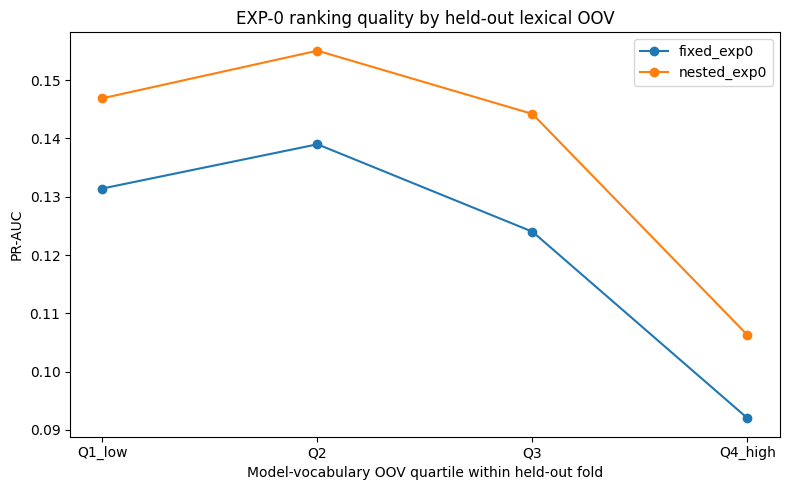

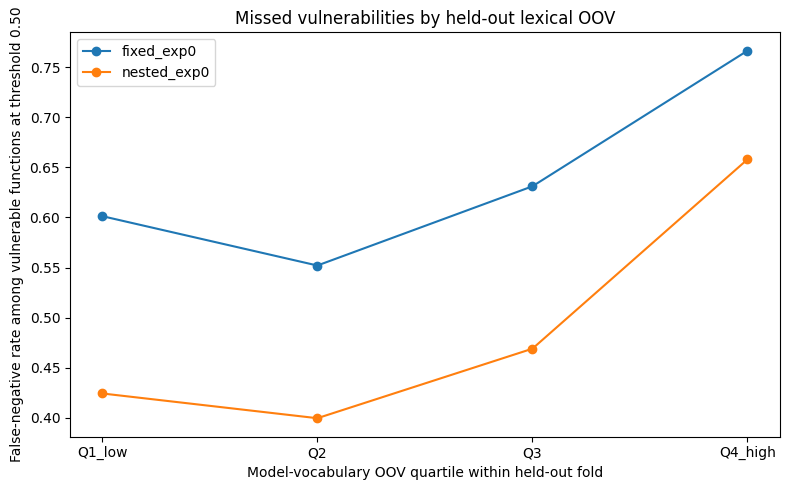

Saved figures:
 - /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/diagnostics/exp0_oov_project_vocab_audit_v1/plots/cs1_exp0_pr_auc_by_model_vocab_oov_quartile.png
 - /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/diagnostics/exp0_oov_project_vocab_audit_v1/plots/cs1_exp0_vulnerable_fnr_by_model_vocab_oov_quartile.png


In [7]:
# ============================================================================
# 7. Optional report figures — descriptive only, generated from saved diagnostics
# ============================================================================

import matplotlib.pyplot as plt

PLOT_DIR = DIAGNOSTIC_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ordered_quartiles = ['Q1_low', 'Q2', 'Q3', 'Q4_high']
pooled = quartile_summary_df.loc[
    quartile_summary_df['scope'] == 'pooled_across_frozen_development_folds'
].copy()

# PR-AUC by model-vocabulary OOV quartile.
plt.figure(figsize=(8, 5))
for model_name, subset in pooled.groupby('model', sort=True):
    subset = subset.set_index('model_vocab_oov_quartile_within_fold').reindex(ordered_quartiles)
    plt.plot(ordered_quartiles, subset['pr_auc'], marker='o', label=model_name)
plt.xlabel('Model-vocabulary OOV quartile within held-out fold')
plt.ylabel('PR-AUC')
plt.title('EXP-0 ranking quality by held-out lexical OOV')
plt.legend()
plt.tight_layout()
pr_auc_plot_path = PLOT_DIR / 'cs1_exp0_pr_auc_by_model_vocab_oov_quartile.png'
plt.savefig(pr_auc_plot_path, dpi=180)
plt.show()

# Vulnerable-function false-negative rate by OOV quartile at the fixed 0.50 threshold.
plt.figure(figsize=(8, 5))
for model_name, subset in pooled.groupby('model', sort=True):
    subset = subset.set_index('model_vocab_oov_quartile_within_fold').reindex(ordered_quartiles)
    plt.plot(ordered_quartiles, subset['vulnerable_false_negative_rate_at_050'], marker='o', label=model_name)
plt.xlabel('Model-vocabulary OOV quartile within held-out fold')
plt.ylabel('False-negative rate among vulnerable functions at threshold 0.50')
plt.title('Missed vulnerabilities by held-out lexical OOV')
plt.legend()
plt.tight_layout()
fnr_plot_path = PLOT_DIR / 'cs1_exp0_vulnerable_fnr_by_model_vocab_oov_quartile.png'
plt.savefig(fnr_plot_path, dpi=180)
plt.show()

print('Saved figures:')
print(' -', pr_auc_plot_path)
print(' -', fnr_plot_path)
